# ResMill Tutorial

This notebook demonstrates how to use `resmill` to create 3D geological reservoir models.

We'll cover:
1. Creating individual layers (Lobe, Gaussian, Channel)
2. Stacking layers into a reservoir
3. Visualizing models with cube slices and cross-sections

In [1]:
import numpy as np
import resmill as gr
from resmill.layers.channel import PV_SHOESTRING, CB_JIGSAW
%matplotlib inline

# Default 64×64×32 grid used by every tutorial / interactive / dataset config.
GRID = dict(nx=64, ny=64, nz=32, x_len=640, y_len=640, z_len=32, top_depth=5000)

## 1. Lobe Layer

Turbidite lobe deposition with compensational stacking. Lobes are deposited iteratively
with probability weighted by surface topography (compensation principle).

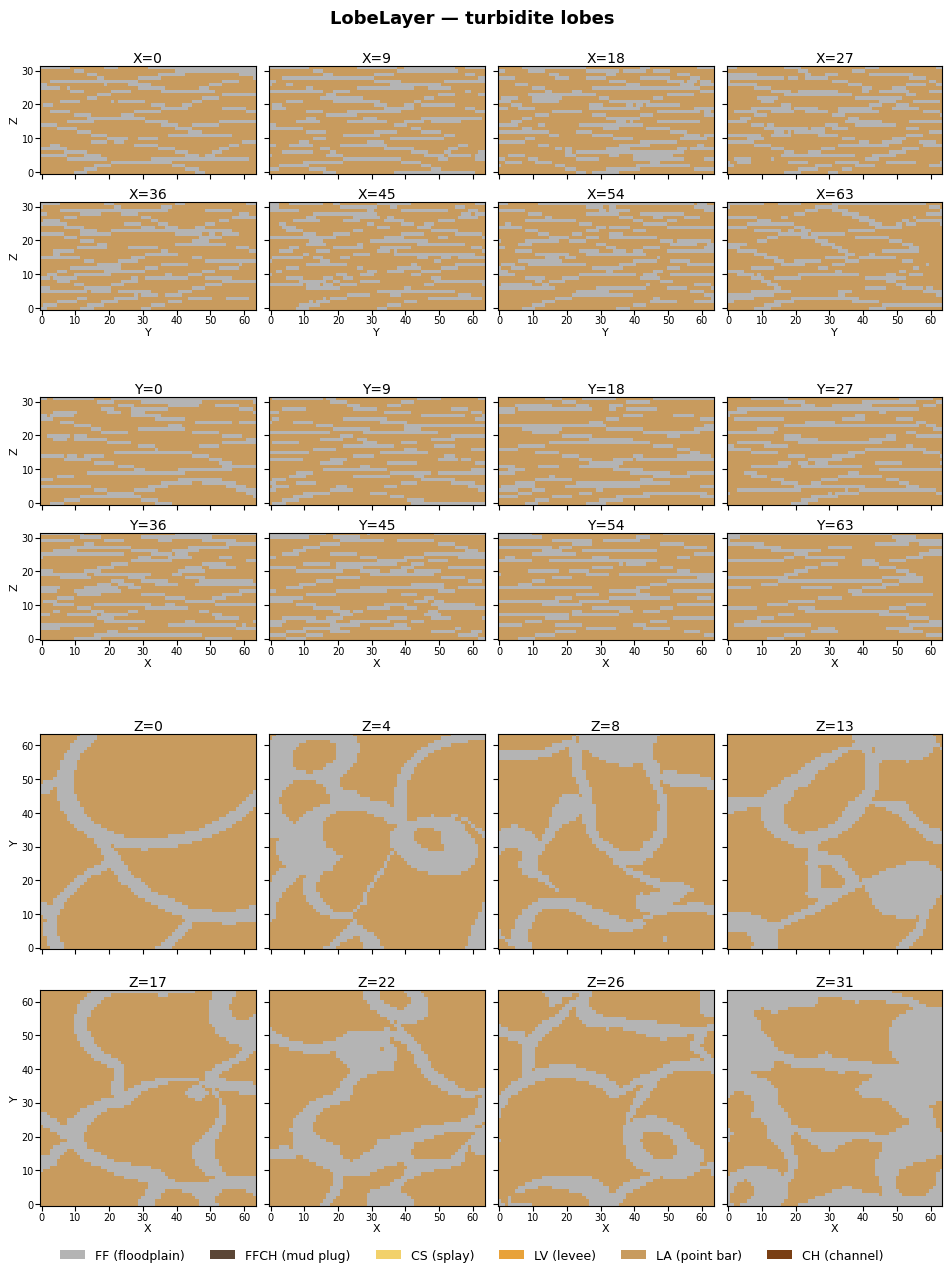

NTG= 70.0%  FF=30.0%  LA=70.0%


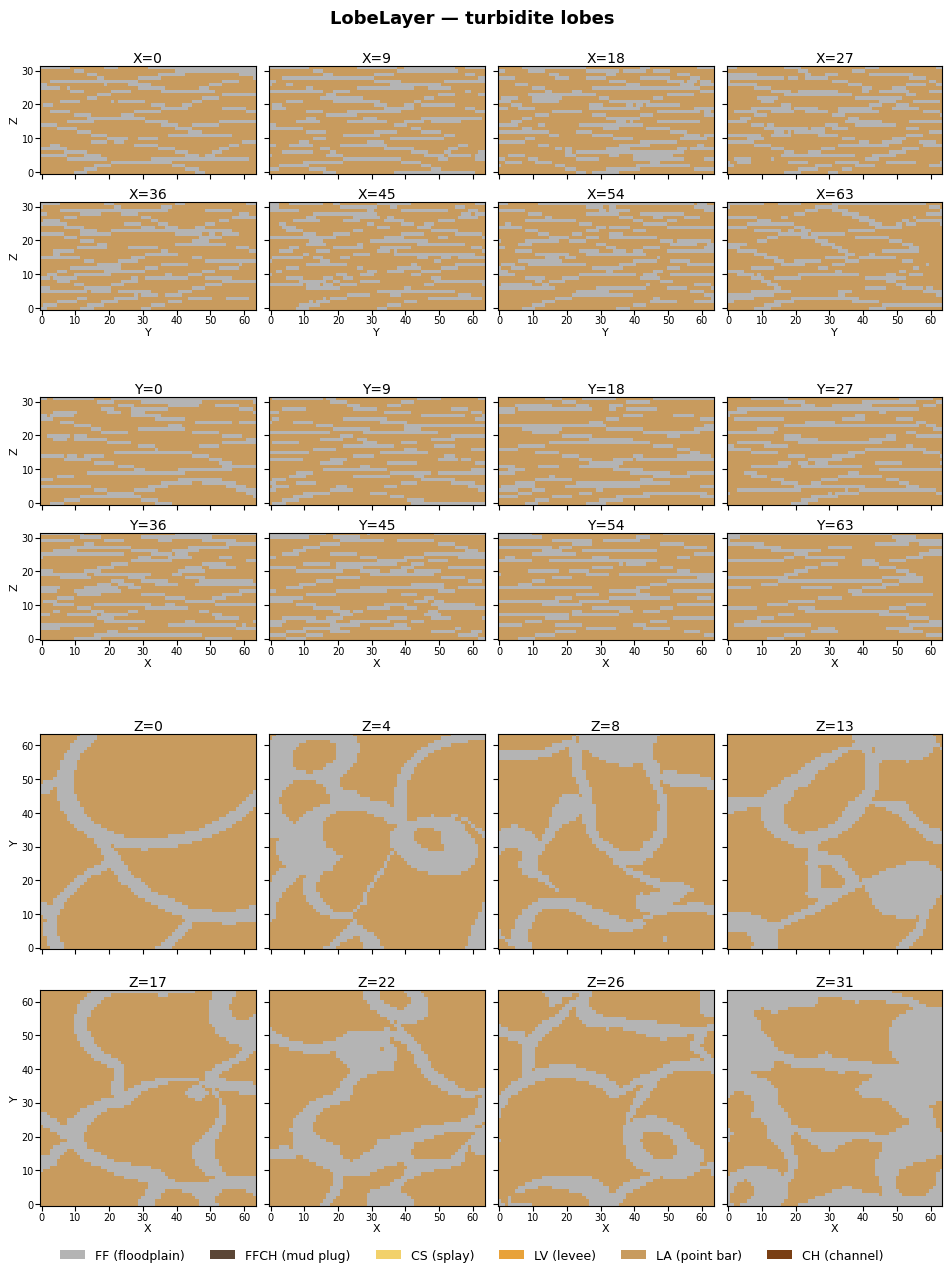

In [2]:
lobe = gr.LobeLayer(**GRID)
lobe.create_geology(
    poro_ave=0.20, perm_ave=1.5,
    poro_std=0.03, perm_std=0.5,
    ntg=0.7,
    rmin=15, rmax=25, asp=1.5, m=100,
    upthinning=False,
)
gr.plot_slices(lobe, title='LobeLayer — turbidite lobes')

(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': 'Lobe Porosity'}, xlabel='X', ylabel='Y', zlabel='Z'>)

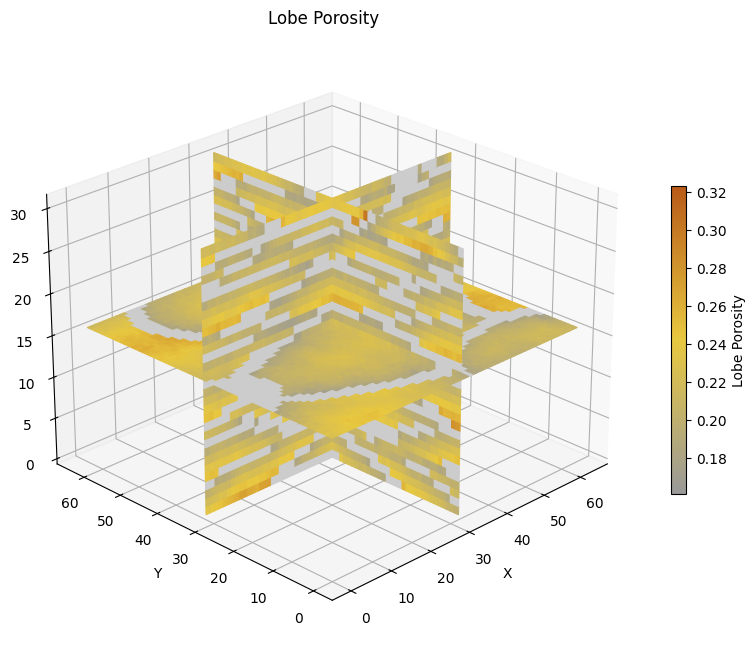

In [3]:
gr.plot_cube_slices(lobe.poro_mat, title='Lobe Porosity')

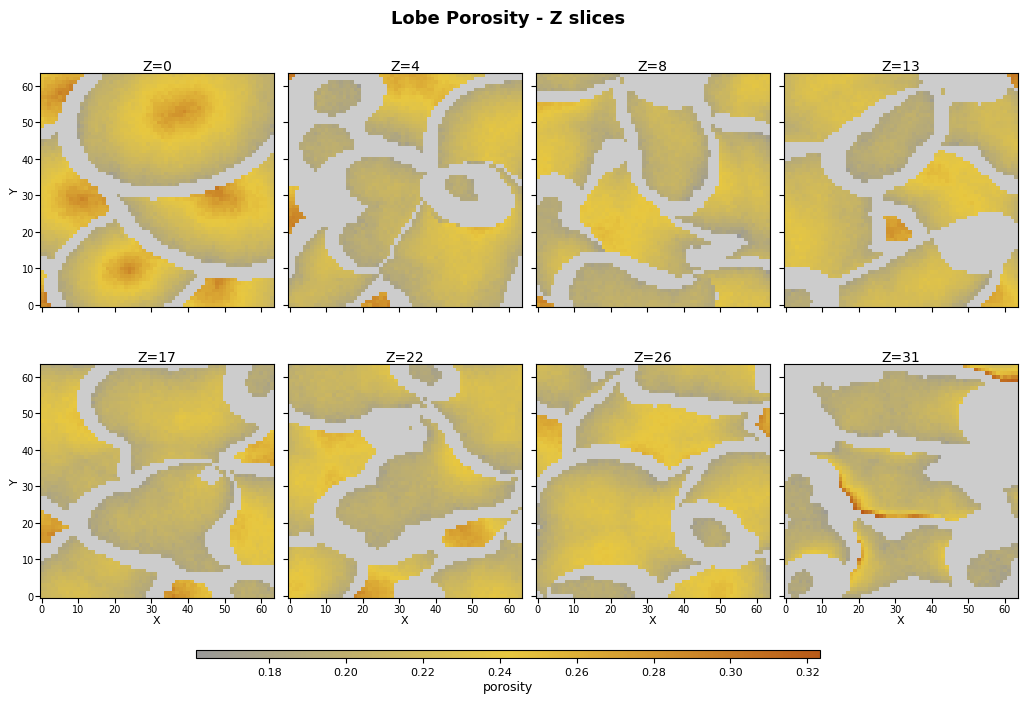

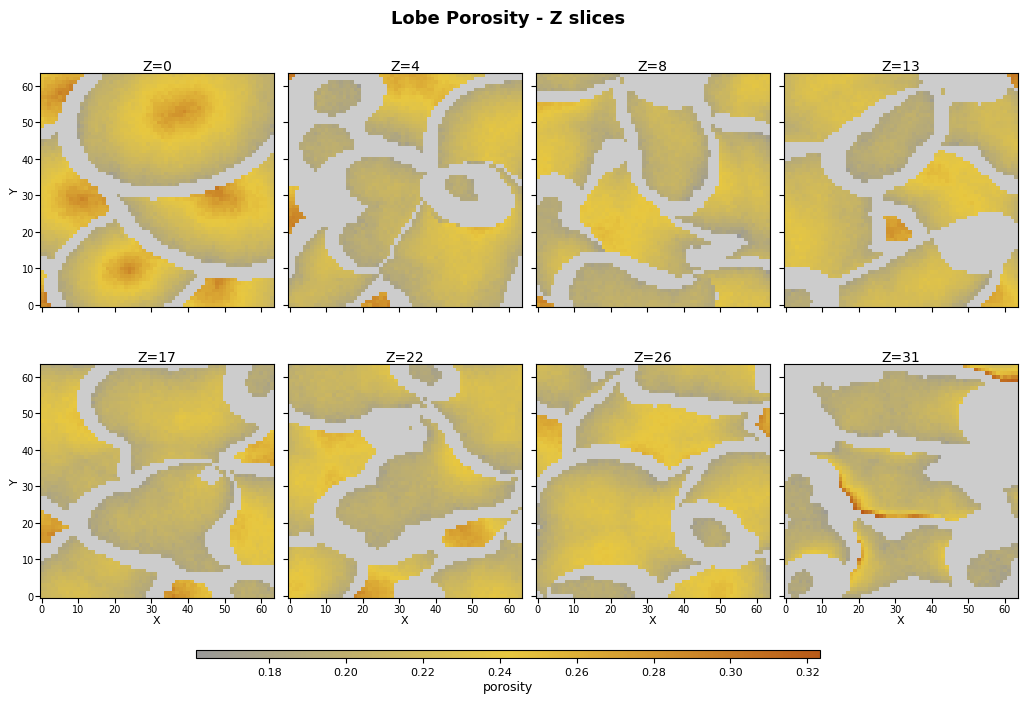

In [4]:
gr.plot_slices(lobe.poro_mat, axis=2, title='Lobe Porosity - Z slices')

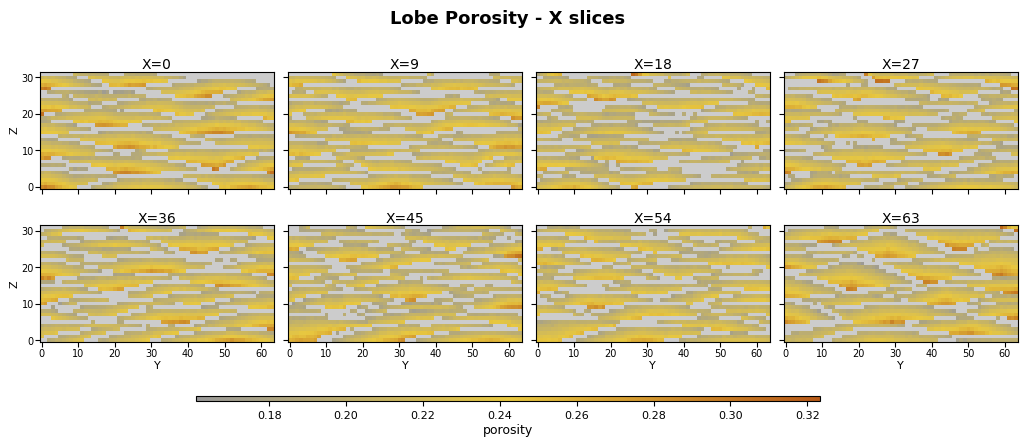

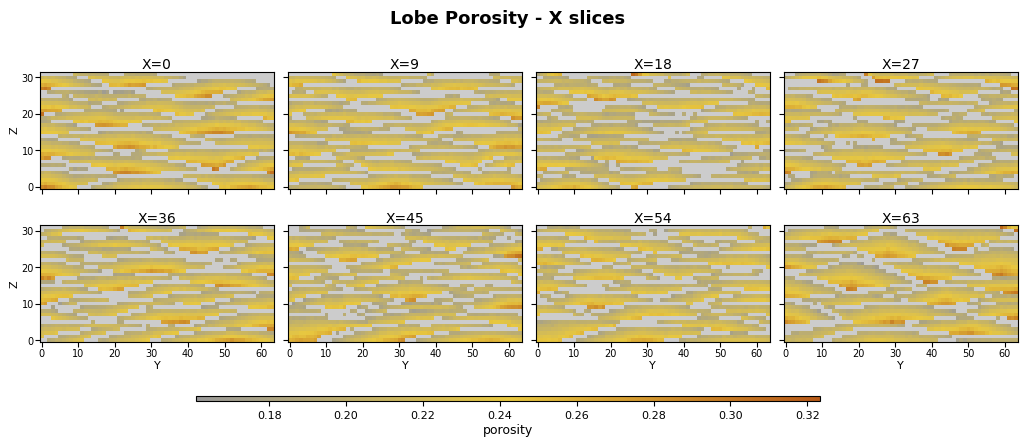

In [5]:
gr.plot_slices(lobe.poro_mat, axis=0, title='Lobe Porosity - X slices')

## 2. Gaussian Layer

Sequential Gaussian simulation creates heterogeneous sand/shale distributions
with spatially correlated properties.

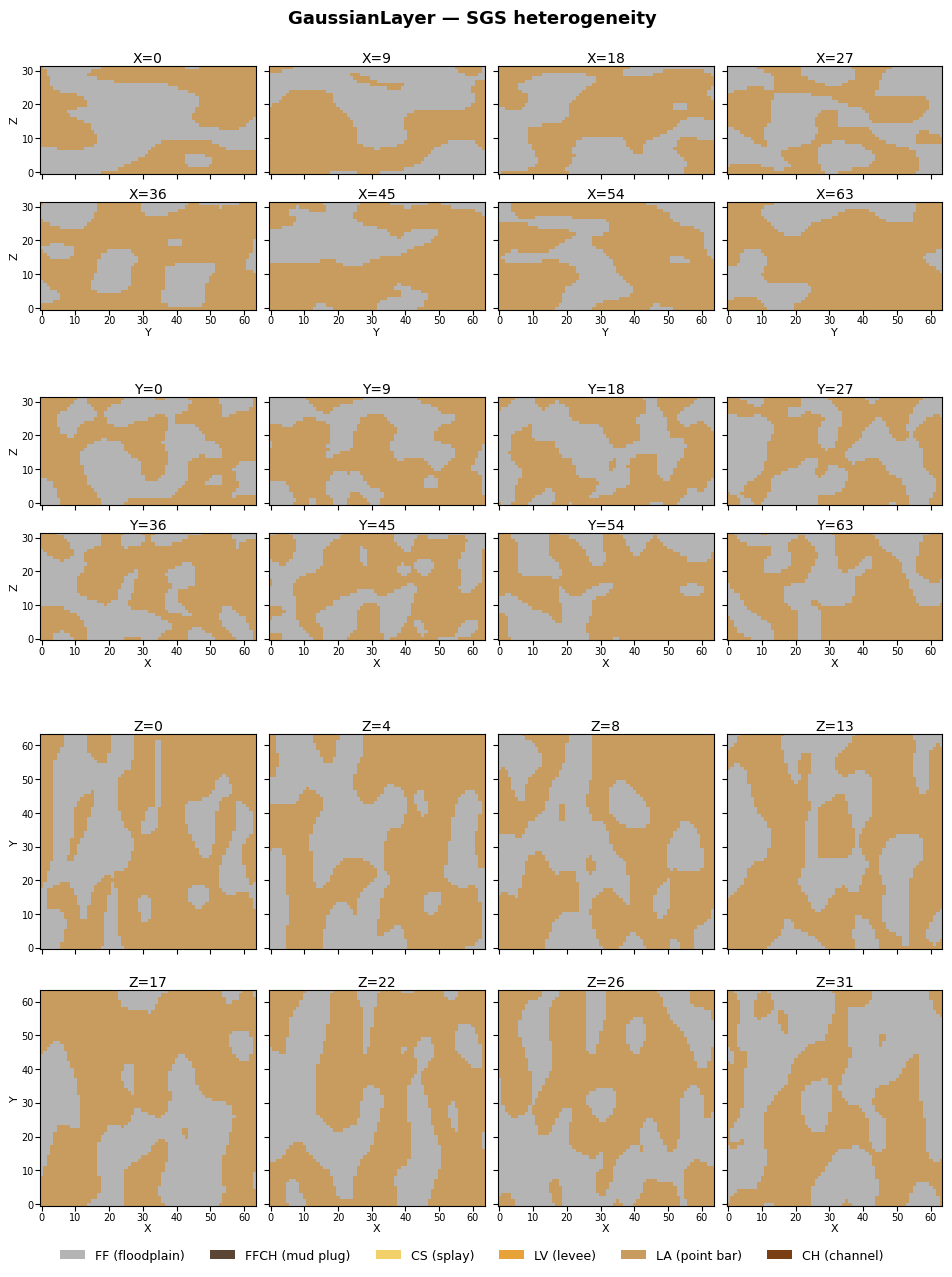

NTG= 60.0%  FF=40.0%  LA=60.0%


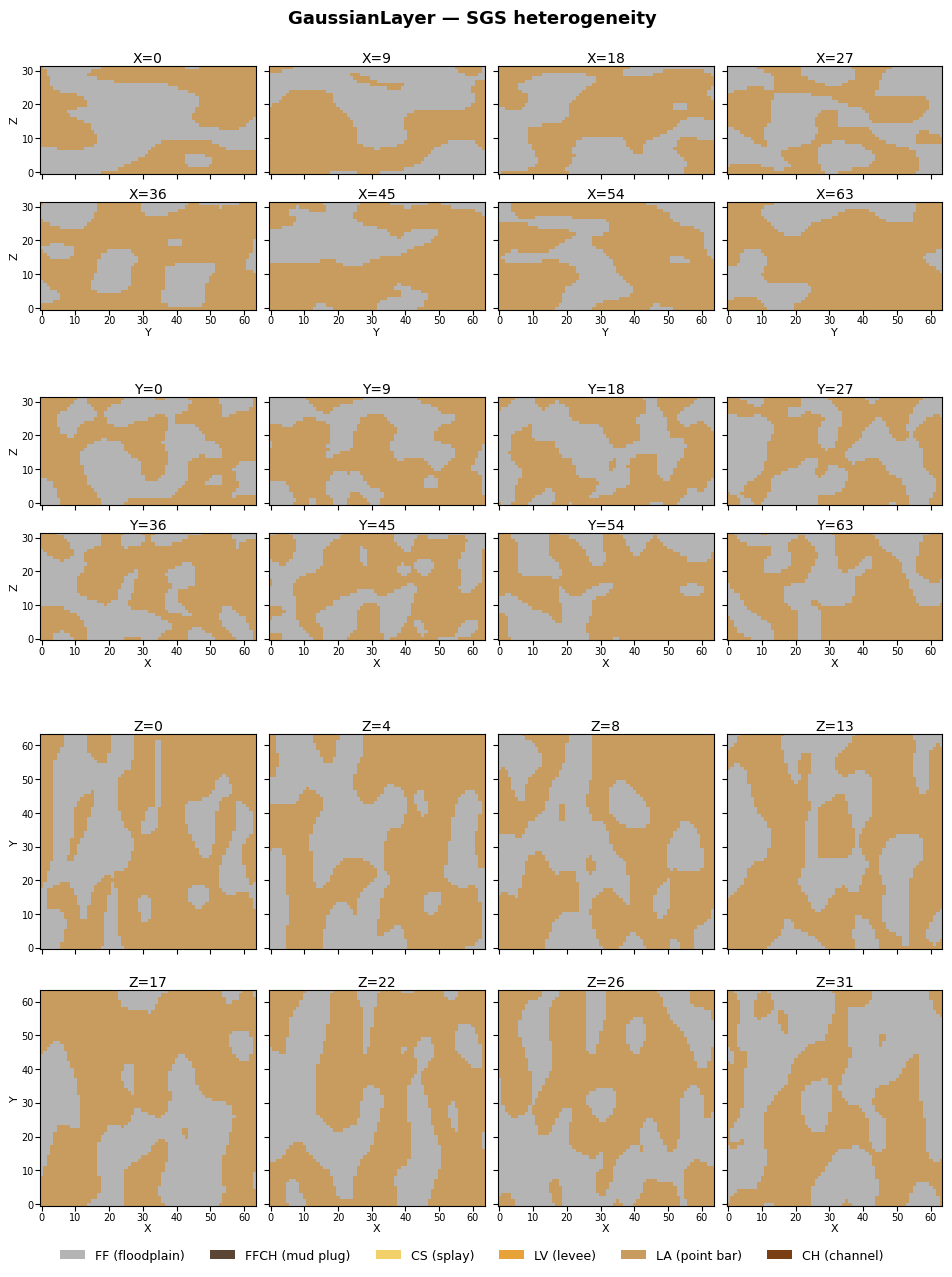

In [6]:
gauss = gr.GaussianLayer(**GRID)
gauss.create_geology(
    poro_ave=0.20, perm_ave=1.5,
    poro_std=0.03, perm_std=0.4,
    ntg=0.6,
    facies_filter=(2.5, 5.0, 2.5),
    sand_filter=(1.5, 2.5, 1.5),
)
gr.plot_slices(gauss, title='GaussianLayer — SGS heterogeneity')

(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': 'Gaussian Porosity'}, xlabel='X', ylabel='Y', zlabel='Z'>)

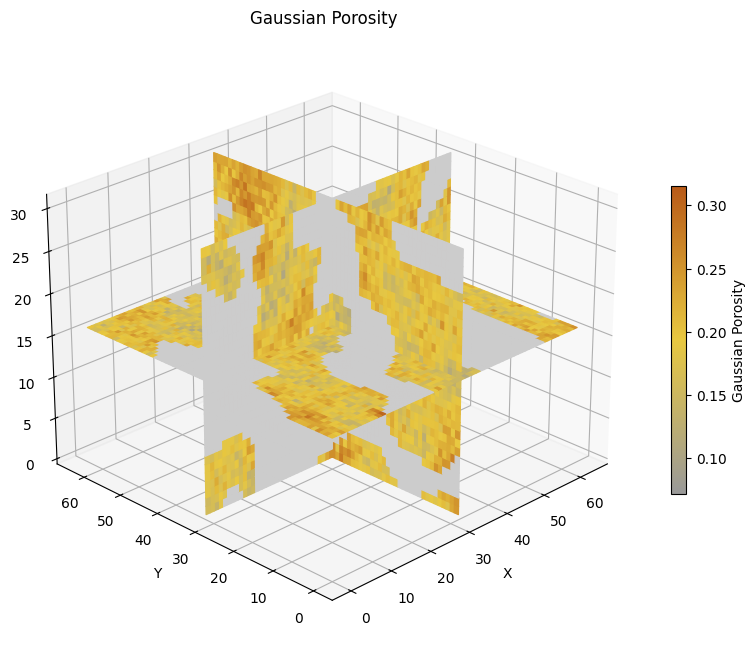

In [7]:
gr.plot_cube_slices(gauss.poro_mat, title='Gaussian Porosity')

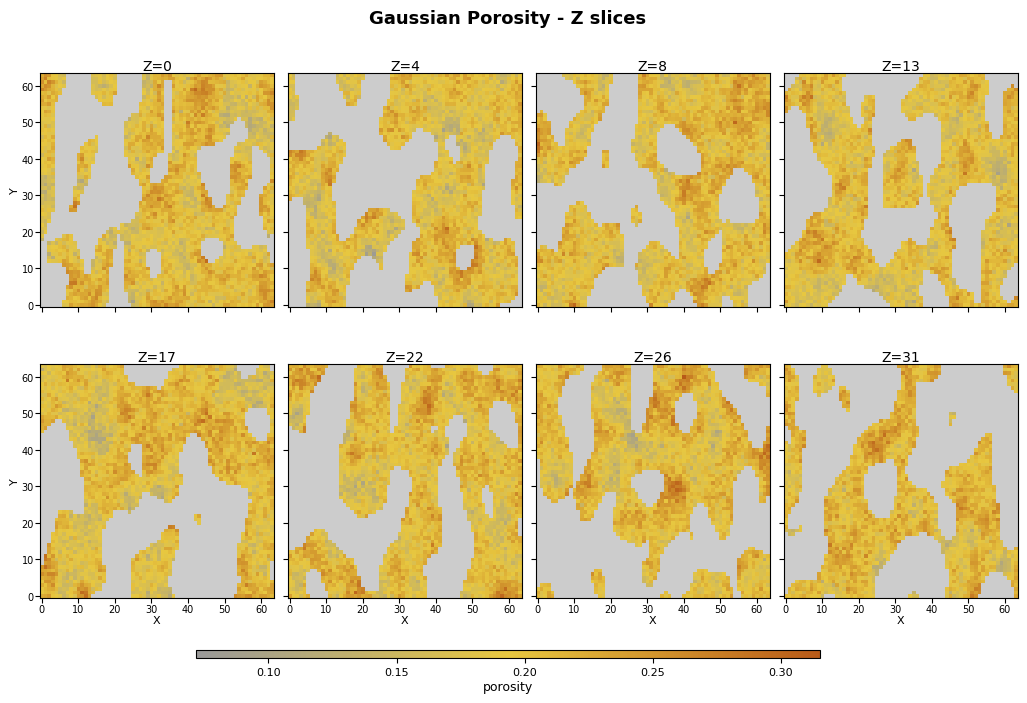

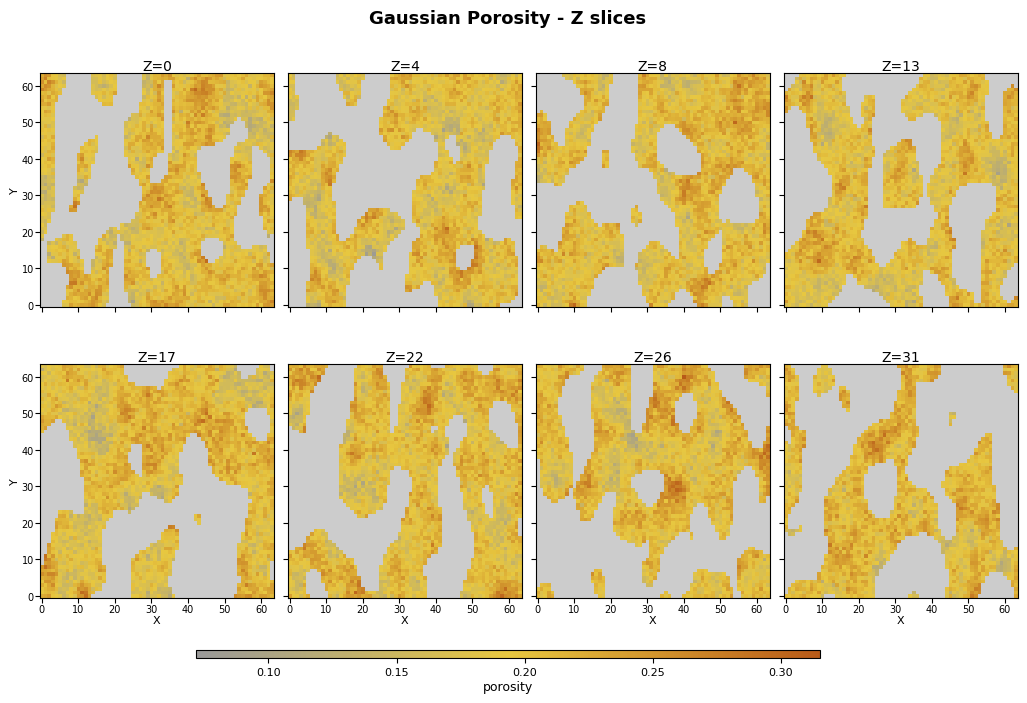

In [8]:
gr.plot_slices(gauss.poro_mat, axis=2, title='Gaussian Porosity - Z slices')

### Effect of filter lengths

Larger filter values create smoother, more continuous geological bodies.

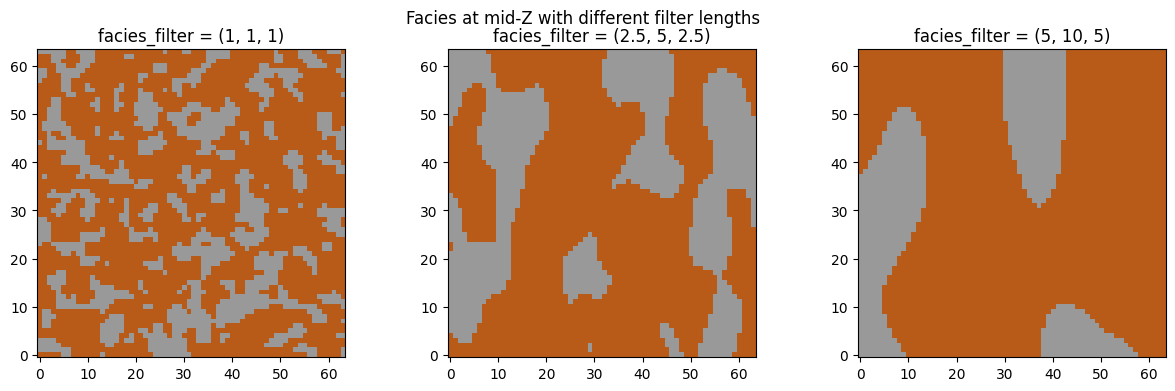

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
filters = [(1, 1, 1), (2.5, 5, 2.5), (5, 10, 5)]
for ax, filt in zip(axes, filters):
    g = gr.GaussianLayer(**GRID)
    g.create_geology(poro_ave=0.2, perm_ave=1.5, poro_std=0.03, perm_std=0.5,
                     ntg=0.7, facies_filter=filt)
    ax.imshow(g.active[:, :, GRID['nz'] // 2].T, origin='lower',
              cmap=gr.RESMILL_CMAP, vmin=0, vmax=1)
    ax.set_title(f'facies_filter = {filt}')
fig.suptitle(f'Facies at mid-Z with different filter lengths')
plt.show()

## 3. Meandering Channel Layer

Fluvial-channel system driven by the Alluvsim event-loop engine
(AR(2) walks + Sun-1996 bank-retreat migration + avulsion + neck
cutoff + level aggradation). The five canonical Pyrcz-2004 reservoir
architectures are exposed as `PV_SHOESTRING`, `CB_JIGSAW`,
`CB_LABYRINTH`, `SH_DISTAL`, `SH_PROXIMAL` preset dicts — pass via
`**PRESET` and override individual params on top.

See `tutorial_alluvsim.ipynb` for the full Alluvsim parameter walk-through.

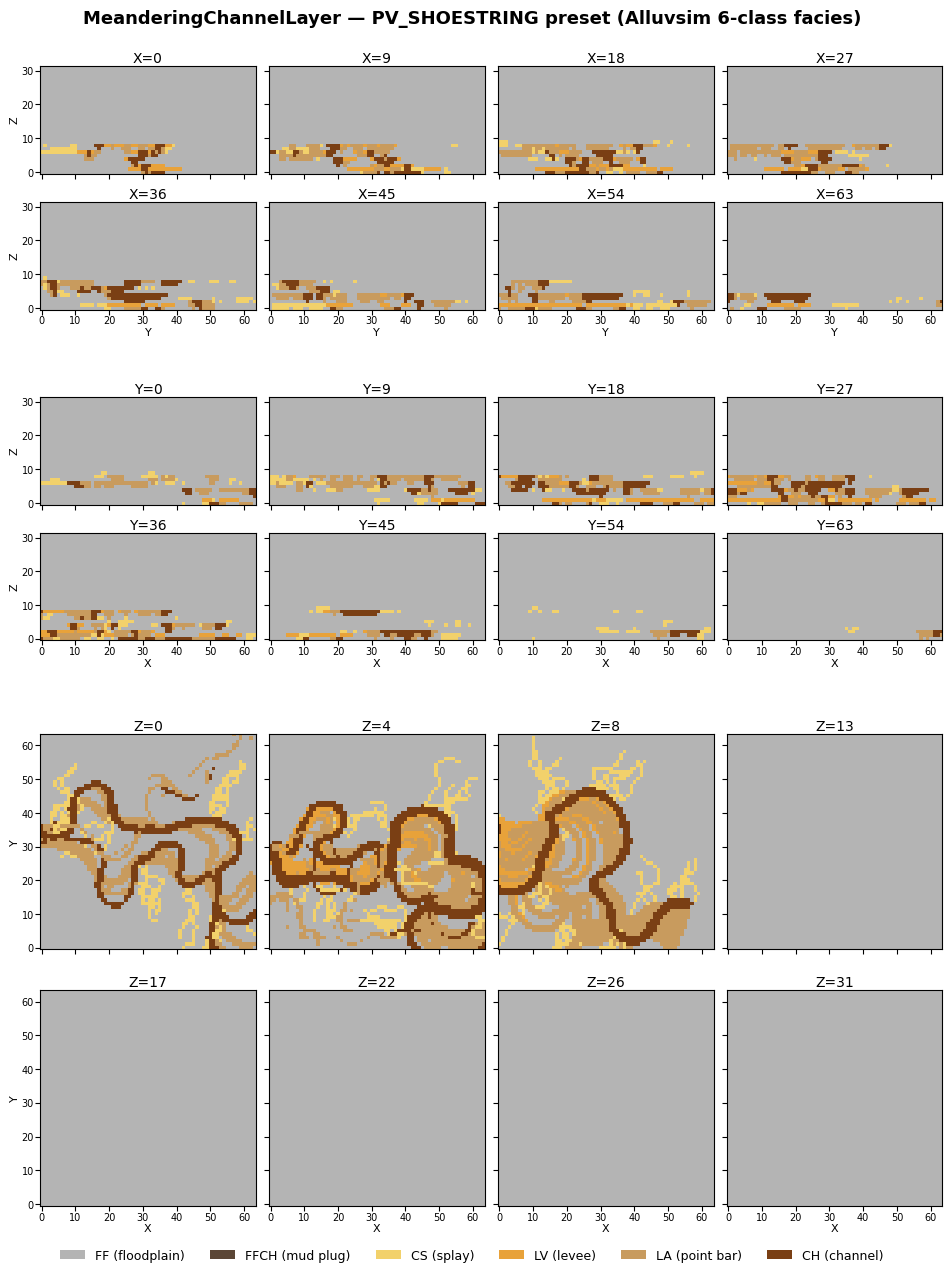

NTG= 10.1%  FF=89.9%  CS=1.7%  LV=1.5%  LA=4.4%  CH=2.6%


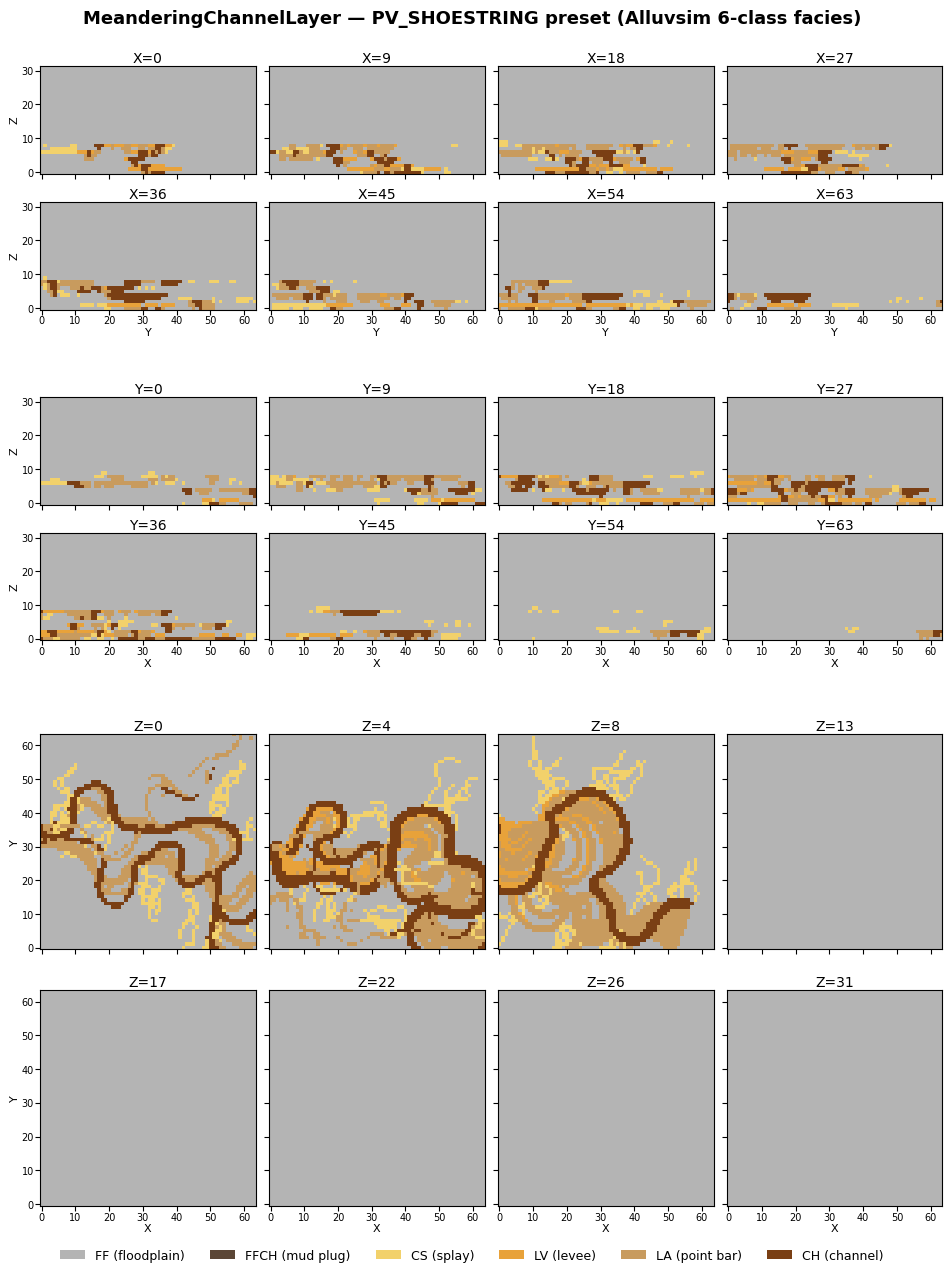

In [10]:
channel = gr.MeanderingChannelLayer(**GRID)
channel.create_geology(seed=42, **PV_SHOESTRING)
gr.plot_slices(channel, title='MeanderingChannelLayer — PV_SHOESTRING preset (Alluvsim 6-class facies)')

(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': 'Channel Porosity'}, xlabel='X', ylabel='Y', zlabel='Z'>)

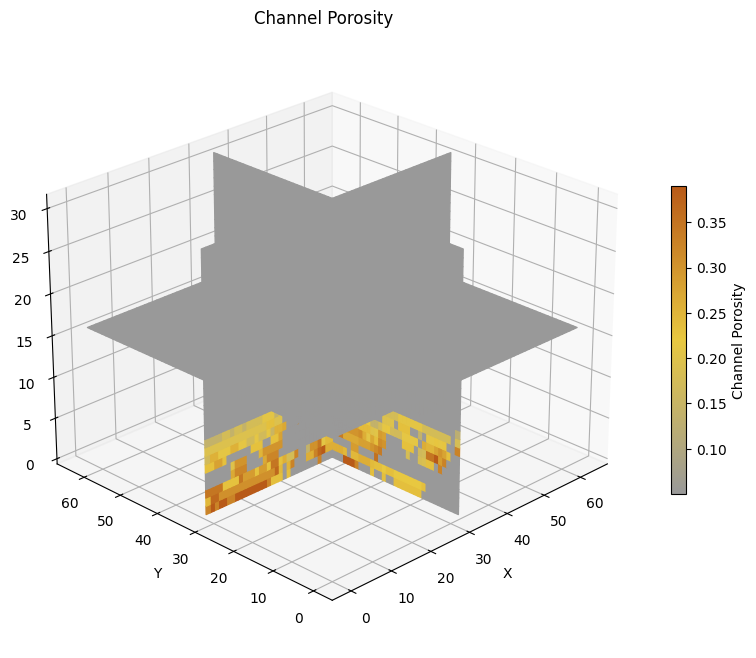

In [11]:
gr.plot_cube_slices(channel.poro_mat, title='Channel Porosity')

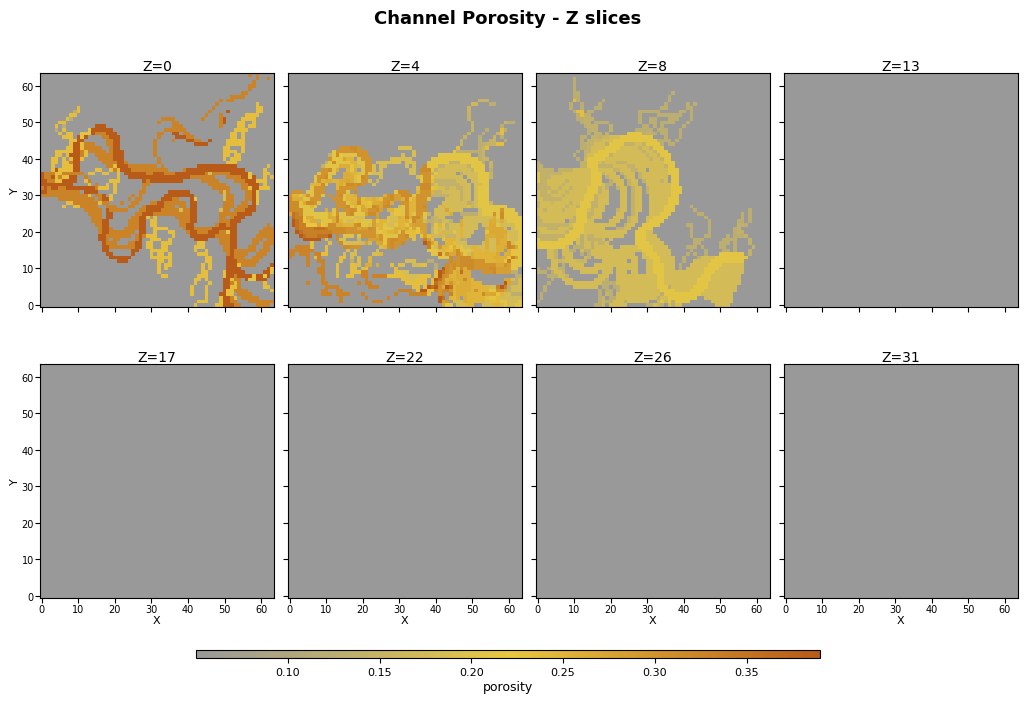

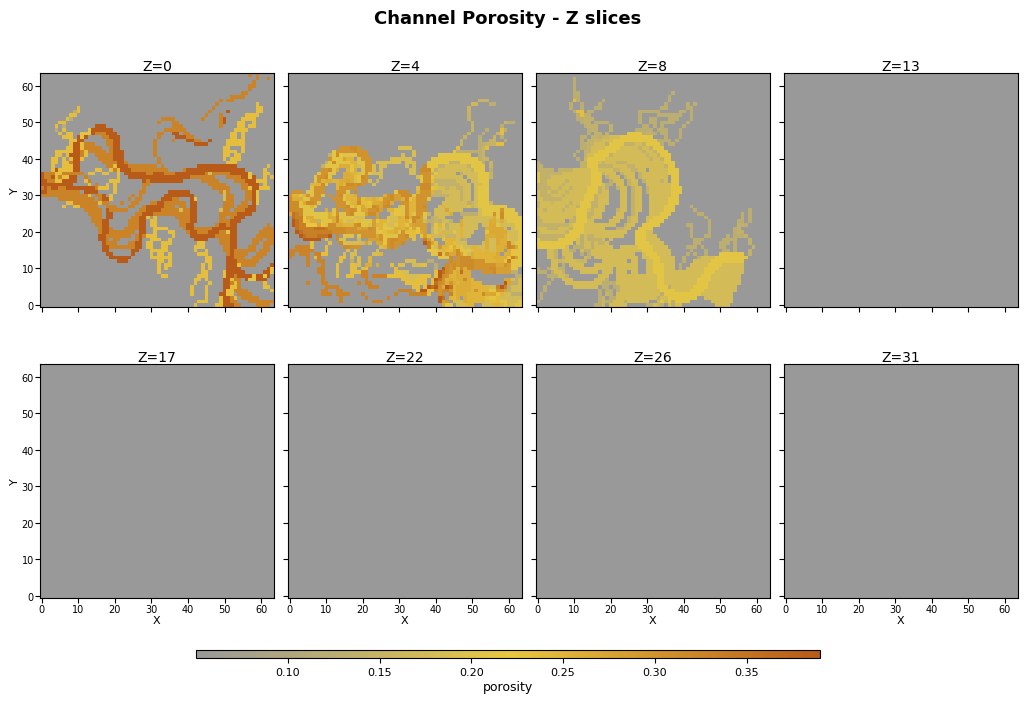

In [12]:
gr.plot_slices(channel.poro_mat, axis=2, title='Channel Porosity - Z slices')

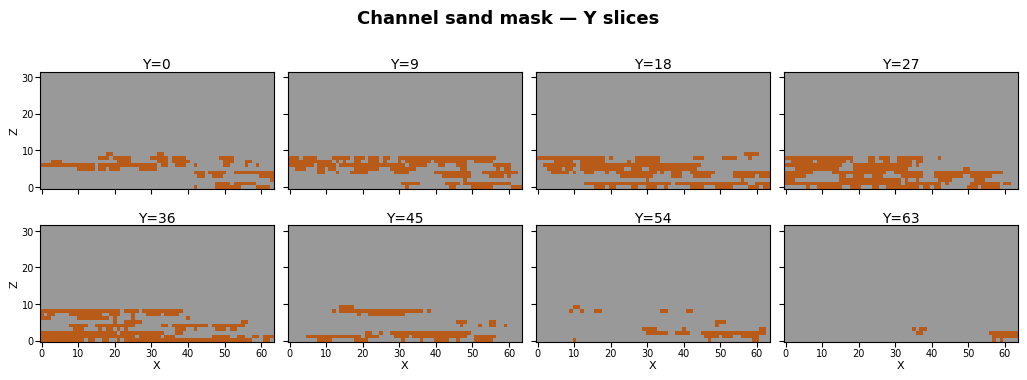

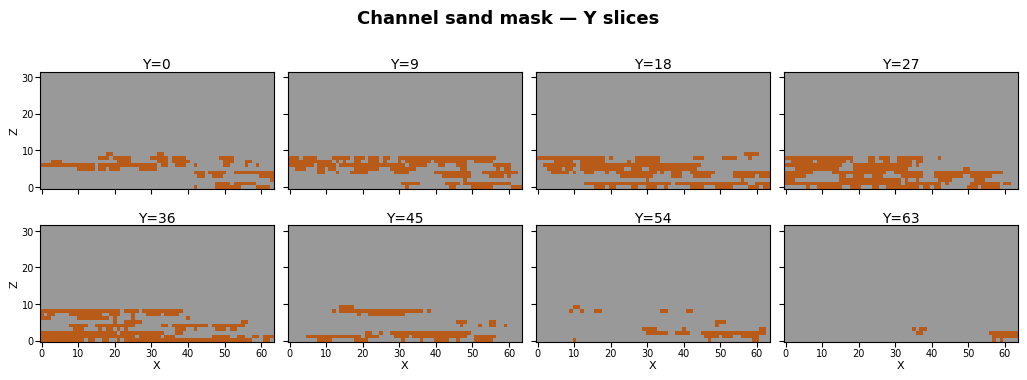

In [13]:
# Binary 0/1 sand mask via .active (auto-detected as binary mode)
gr.plot_slices(channel.active, axis=1, title='Channel sand mask — Y slices')

### Effect of `mCHsinu` (channel sinuosity)

Higher `mCHsinu` → more wandering AR(2) walks → tighter meanders. Sweep:

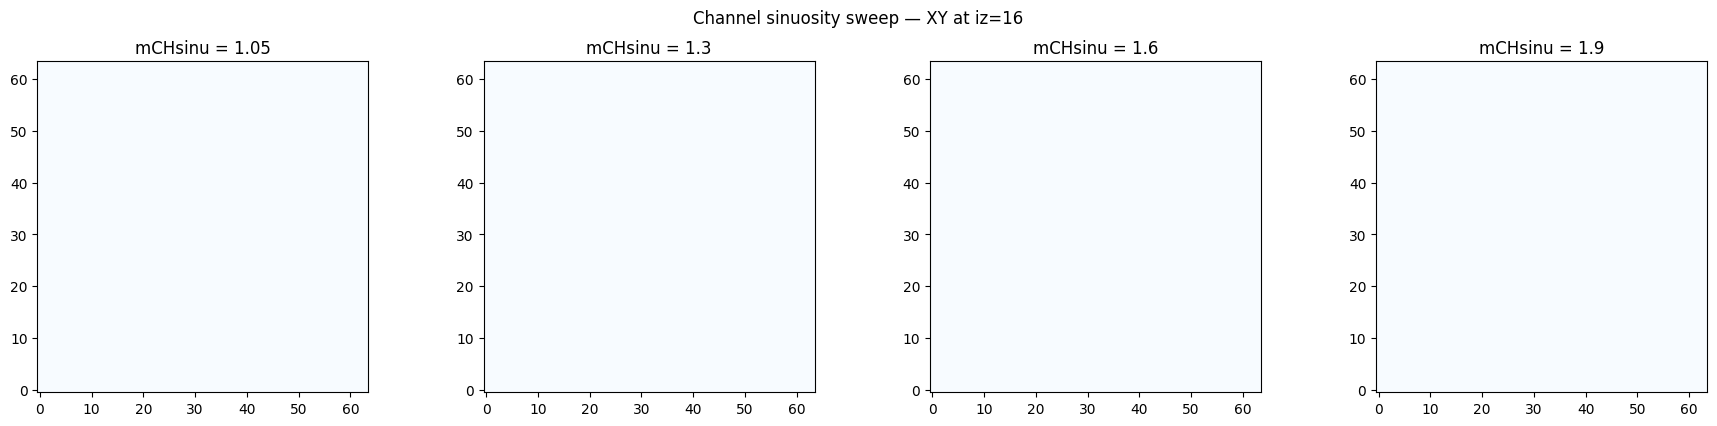

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, sinu in zip(axes, [1.05, 1.30, 1.60, 1.90]):
    c = gr.MeanderingChannelLayer(**GRID)
    c.create_geology(seed=42, **{**PV_SHOESTRING, 'mCHsinu': sinu, 'stdevCHsinu': 0.05})
    iz = GRID['nz'] // 2
    ax.imshow(c.active[:, :, iz].T, origin='lower', cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'mCHsinu = {sinu}')
fig.suptitle(f'Channel sinuosity sweep — XY at iz={GRID["nz"] // 2}')
plt.tight_layout(); plt.show()

## 3b. Braided Channel Layer

Same fluvial engine as `MeanderingChannelLayer`, just with the
`CB_JIGSAW` Pyrcz-2004 preset baked in: shallow wide channels,
aggressive in-model avulsion, prominent FFCH abandonment baffles.
The two classes share the entire Alluvsim parameter surface.

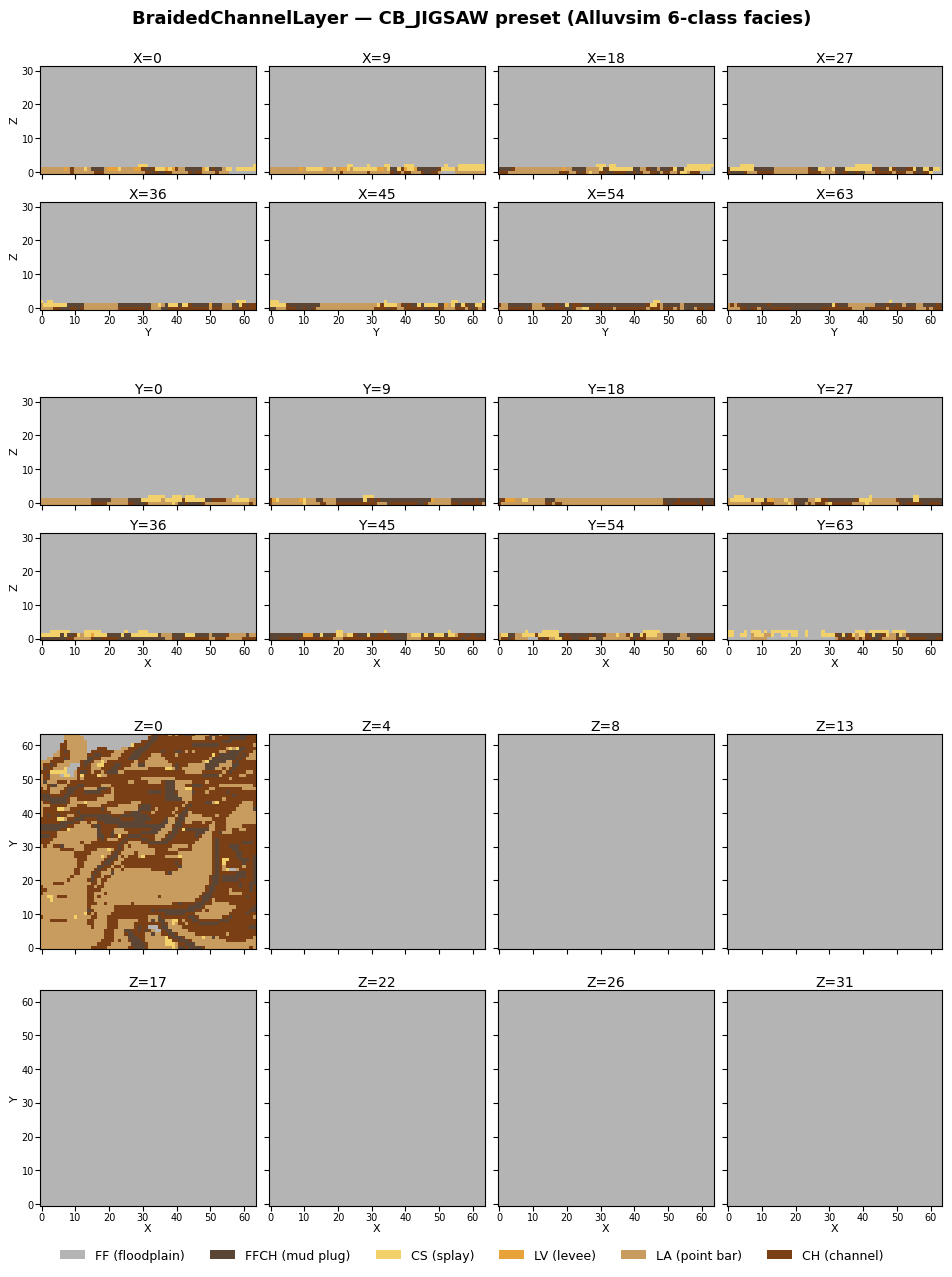

NTG=  5.0%  FF=93.4%  FFCH=1.6%  CS=1.2%  LV=0.1%  LA=2.0%  CH=1.6%


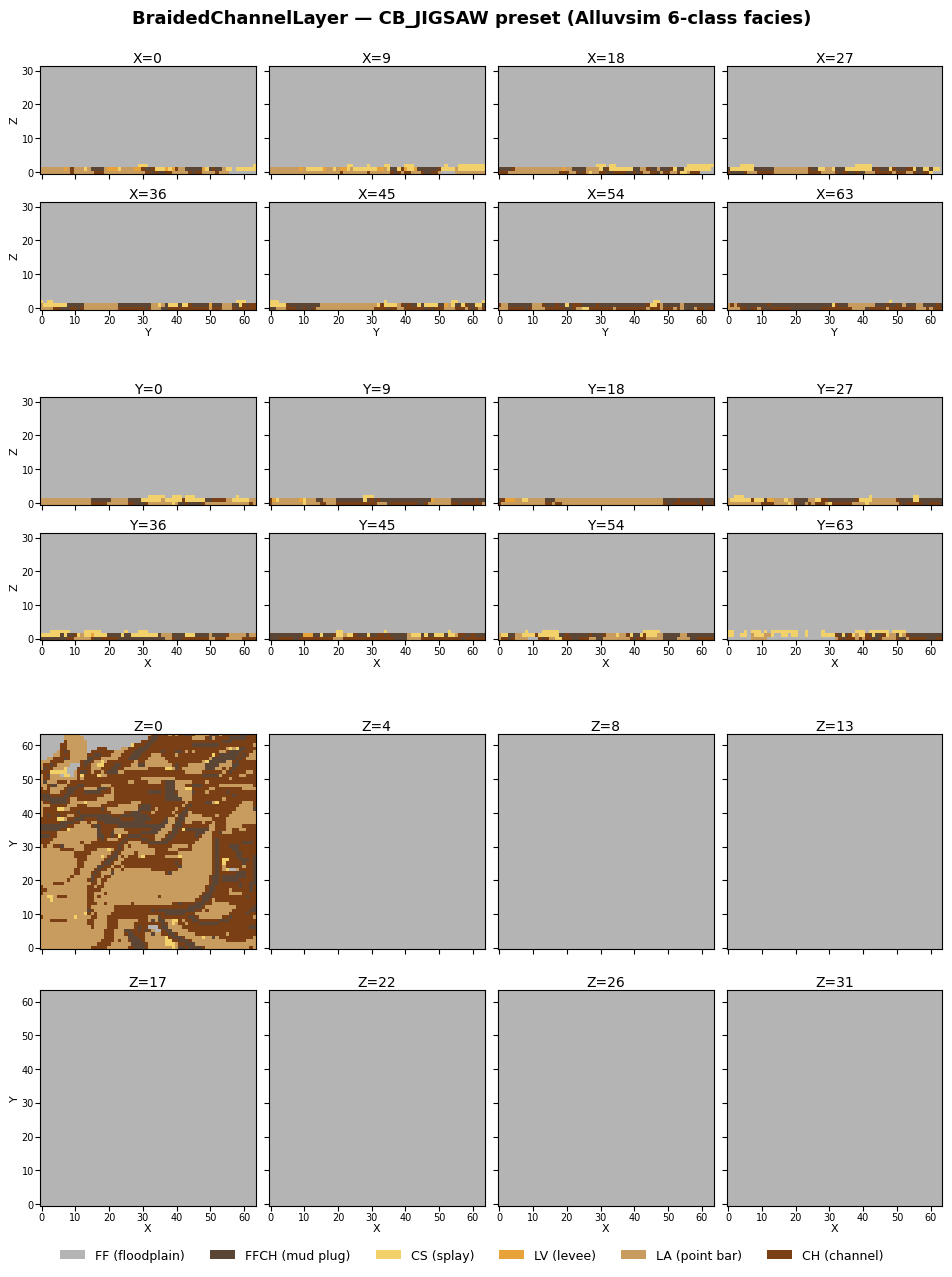

In [15]:
braided = gr.BraidedChannelLayer(**GRID)
braided.create_geology(seed=42)   # CB_JIGSAW defaults are baked in
gr.plot_slices(braided, title='BraidedChannelLayer — CB_JIGSAW preset (Alluvsim 6-class facies)')

(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': 'Braided Channel Porosity'}, xlabel='X', ylabel='Y', zlabel='Z'>)

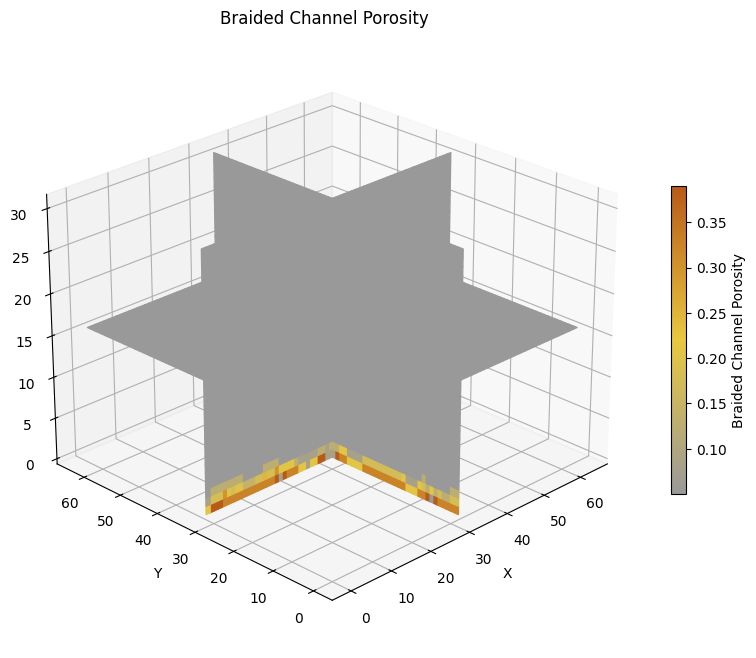

In [16]:
# Per-cell porosity (not just the binary sand mask)
gr.plot_cube_slices(braided.poro_mat, title='Braided Channel Porosity')

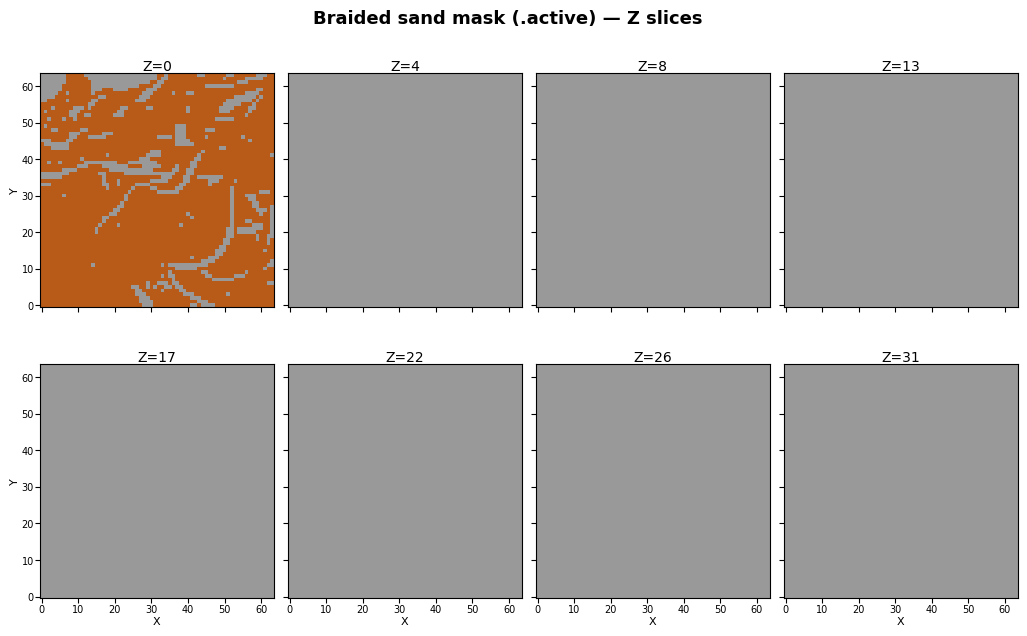

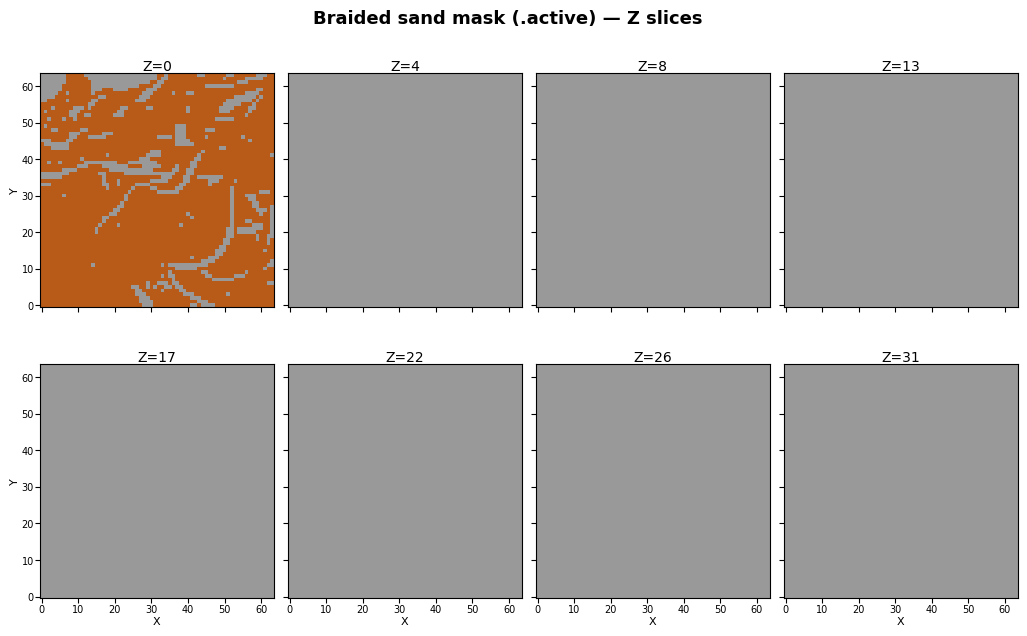

In [17]:
gr.plot_slices(braided.active, axis=2, title='Braided sand mask (.active) — Z slices')

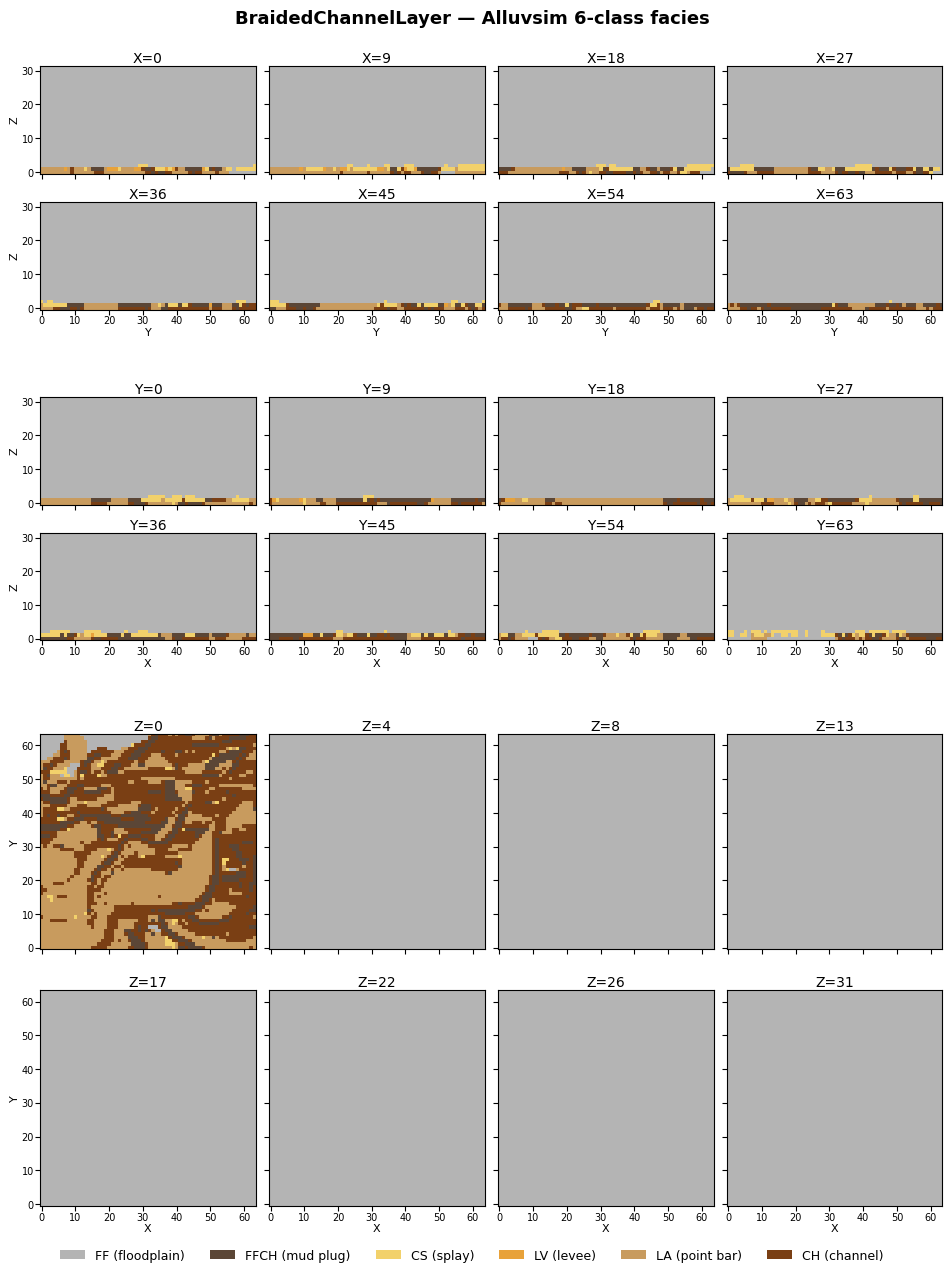

NTG=  5.0%  FF=93.4%  FFCH=1.6%  CS=1.2%  LV=0.1%  LA=2.0%  CH=1.6%


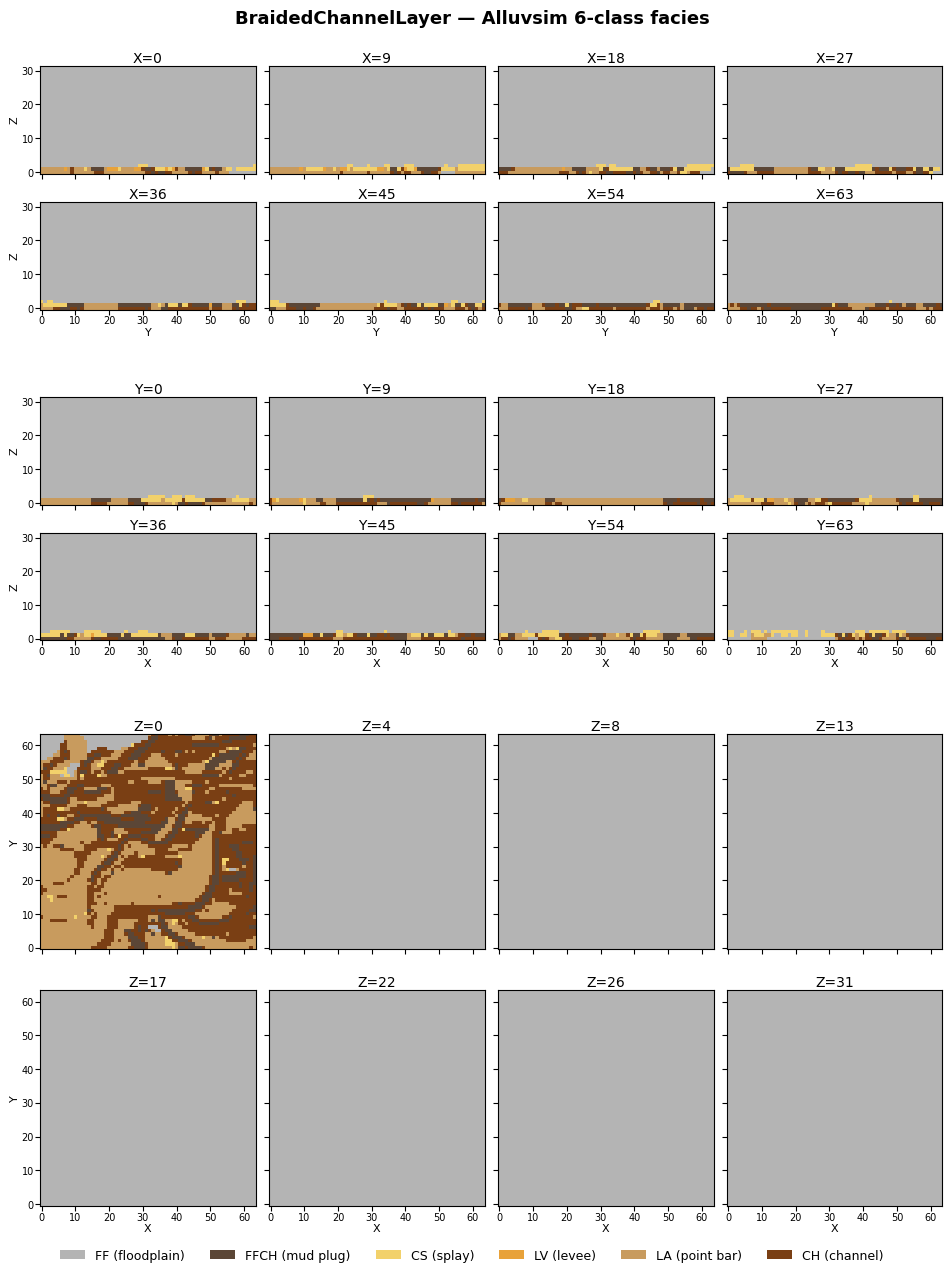

In [18]:
# Multi-panel Alluvsim 6-class view: ``layer.facies`` is now always the
# full FF/FFCH/CS/LV/LA/CH breakdown, ``layer.active`` is the binary
# 0/1 sand mask. Passing the layer to plot_slices auto-picks the
# discrete Alluvsim cmap + legend.
gr.plot_slices(braided, title='BraidedChannelLayer — Alluvsim 6-class facies')

### Meandering vs. Braided comparison

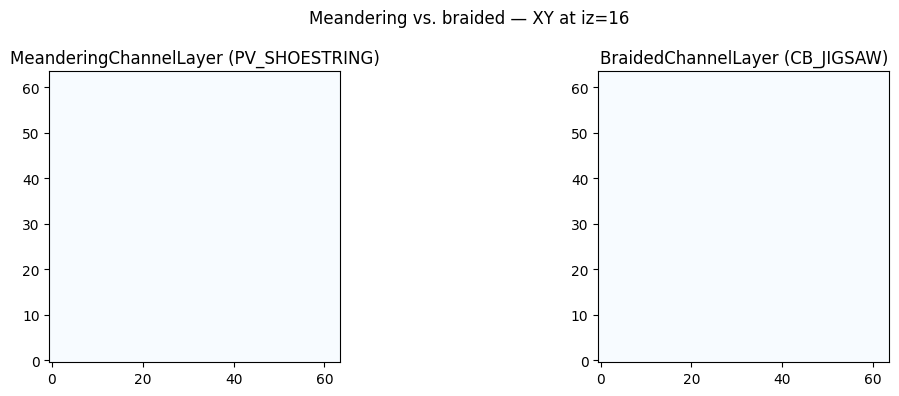

In [19]:
import matplotlib.pyplot as plt

m = gr.MeanderingChannelLayer(**GRID); m.create_geology(seed=42, **PV_SHOESTRING)
b = gr.BraidedChannelLayer(**GRID);    b.create_geology(seed=42)

iz = GRID['nz'] // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(m.active[:, :, iz].T, origin='lower', cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('MeanderingChannelLayer (PV_SHOESTRING)')
axes[1].imshow(b.active[:, :, iz].T, origin='lower', cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('BraidedChannelLayer (CB_JIGSAW)')
fig.suptitle(f'Meandering vs. braided — XY at iz={iz}')
plt.tight_layout(); plt.show()

## 3c. Delta Layer

Distributary-fan delta — subclass of `MeanderingChannelLayer` driving
the same fluvial engine with delta-tuned defaults (`DELTA_FAN`).
Key delta knobs: `trunk_length_fraction` (where bifurcation starts),
`progradation_fraction` (clinoform), `branch_spread_deg` (fan-out
angle), `paint_mouth_bars` (bars at distal tips).

See `tutorial_delta.ipynb` for the full delta walkthrough.

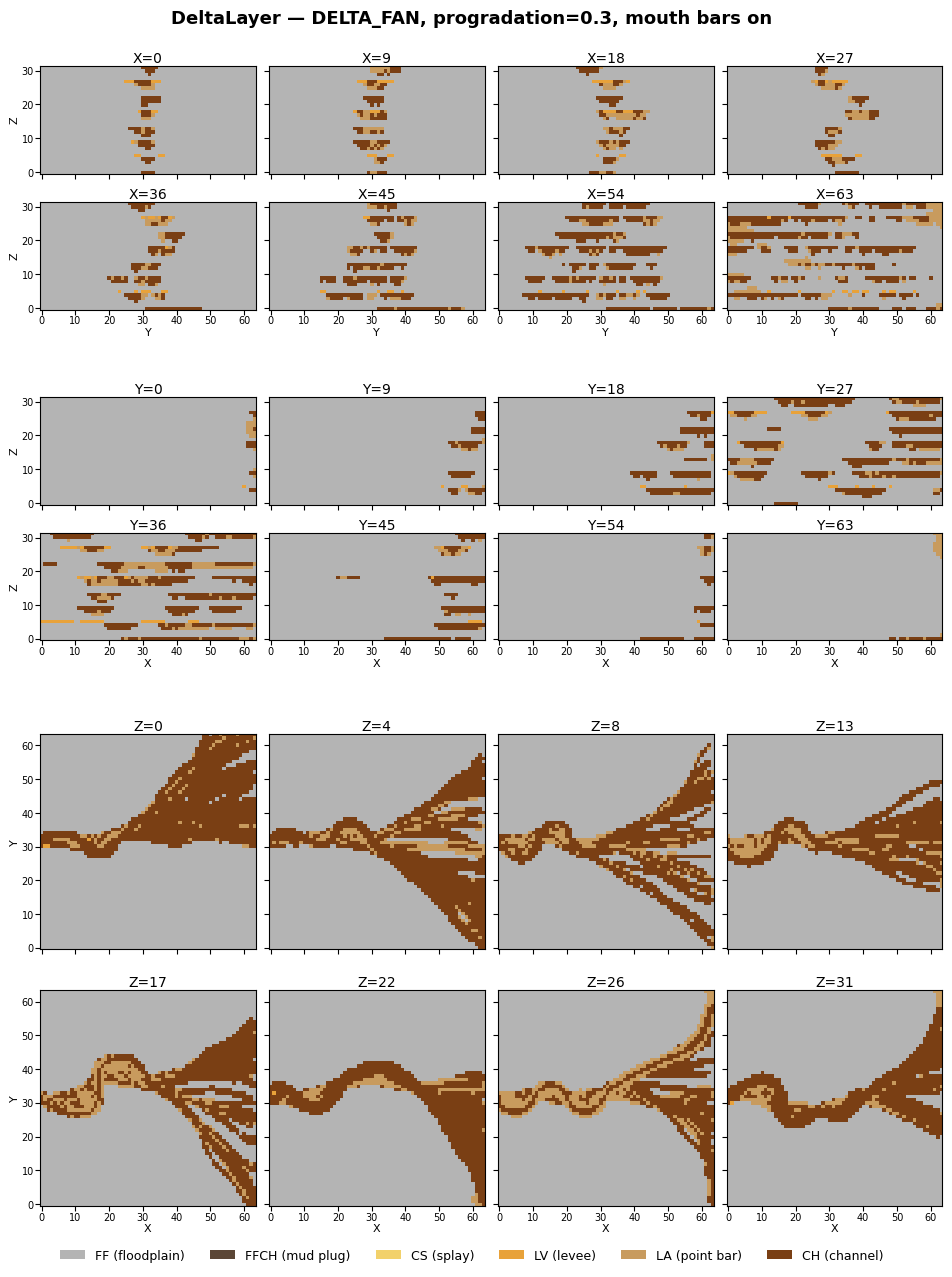

NTG= 11.9%  FF=88.1%  LV=0.7%  LA=2.6%  CH=8.7%


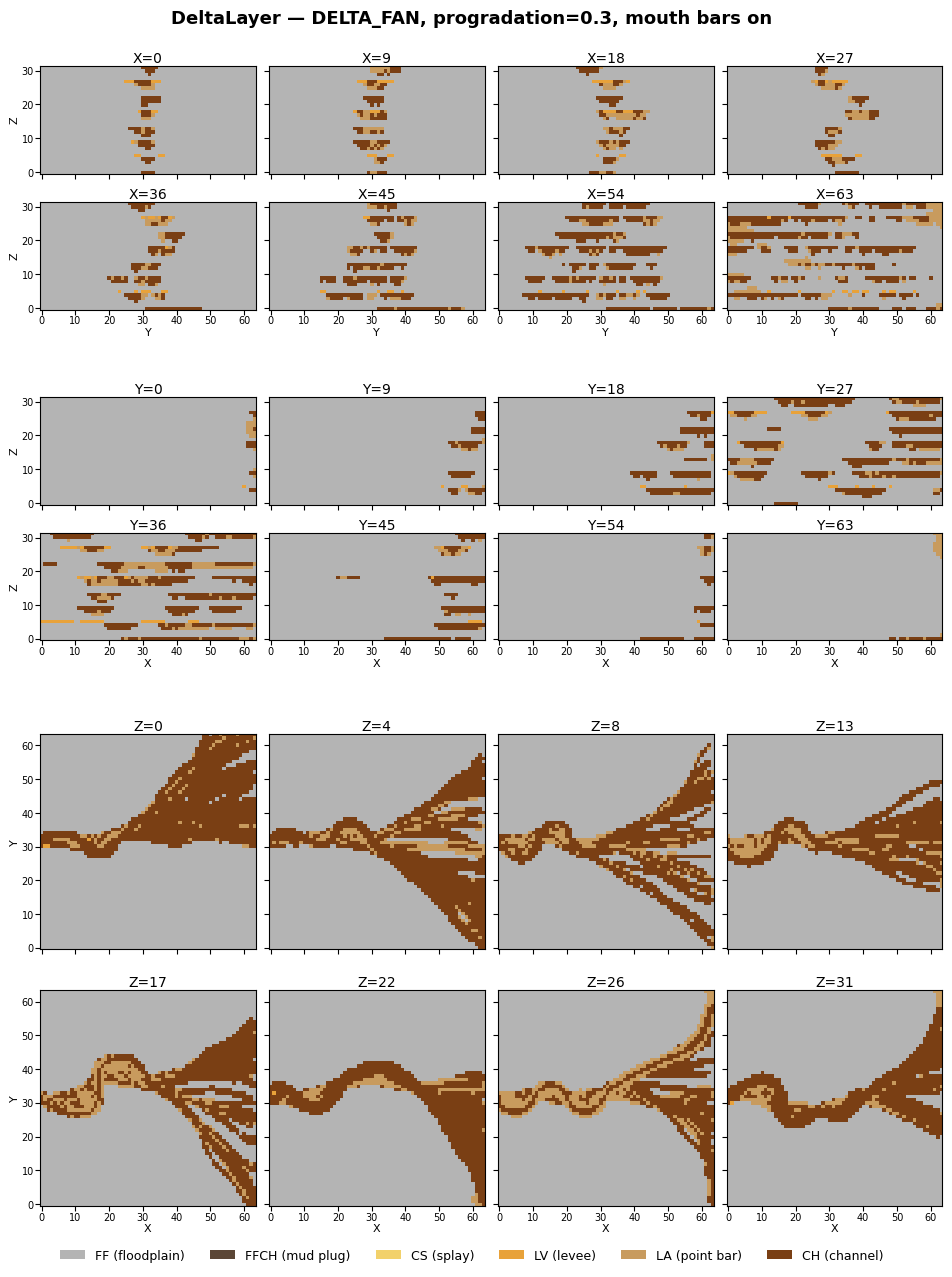

In [20]:
delta = gr.DeltaLayer(**GRID)
delta.create_geology(seed=42, progradation_fraction=0.3, paint_mouth_bars=True)
gr.plot_slices(delta, title='DeltaLayer — DELTA_FAN, progradation=0.3, mouth bars on')

## 4. Multi-Layer Reservoir

Stack different layer types into a single reservoir. Layers must have matching
lateral dimensions (nx, ny, x_len, y_len) and be vertically contiguous.

In [21]:
# Three contiguous layers with matching nx, ny, x_len, y_len.
nx, ny = 64, 64
x_len, y_len = 640, 640

l1 = gr.LobeLayer(nx=nx, ny=ny, nz=12, x_len=x_len, y_len=y_len,
                  z_len=24, top_depth=5000, dip=2.0)
l1.create_geology(poro_ave=0.22, perm_ave=1.8, poro_std=0.03, perm_std=0.5,
                  ntg=0.75, rmin=12, rmax=22, upthinning=False)

l2 = gr.GaussianLayer(nx=nx, ny=ny, nz=10, x_len=x_len, y_len=y_len,
                      z_len=20, top_depth=5024, dip=2.0)
l2.create_geology(poro_ave=0.15, perm_ave=1.0, poro_std=0.02, perm_std=0.4, ntg=0.5)

l3 = gr.MeanderingChannelLayer(nx=nx, ny=ny, nz=10, x_len=x_len, y_len=y_len,
                                z_len=20, top_depth=5044, dip=2.0)
l3.create_geology(seed=42, **PV_SHOESTRING)

reservoir = gr.Reservoir([l1, l2, l3])
print(f'Reservoir shape: {reservoir.poro_mat.shape}   (12 + 10 + 10 = {reservoir.nz} z-cells)')
print(f'Number of layers: {reservoir.n_layers}')

Reservoir shape: (64, 64, 32)   (12 + 10 + 10 = 32 z-cells)
Number of layers: 3


(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': 'Reservoir Porosity'}, xlabel='X', ylabel='Y', zlabel='Z'>)

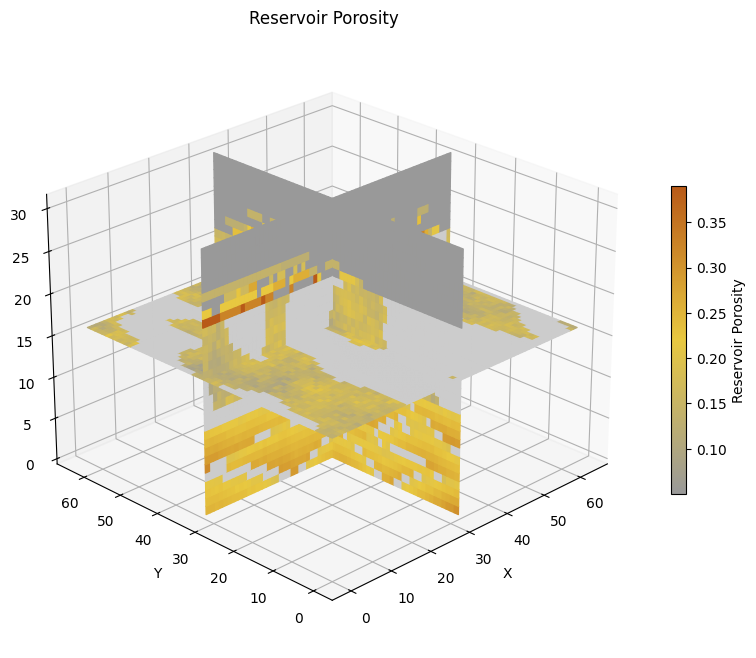

In [22]:
gr.plot_reservoir(reservoir, 'poro_mat', title='Reservoir Porosity')

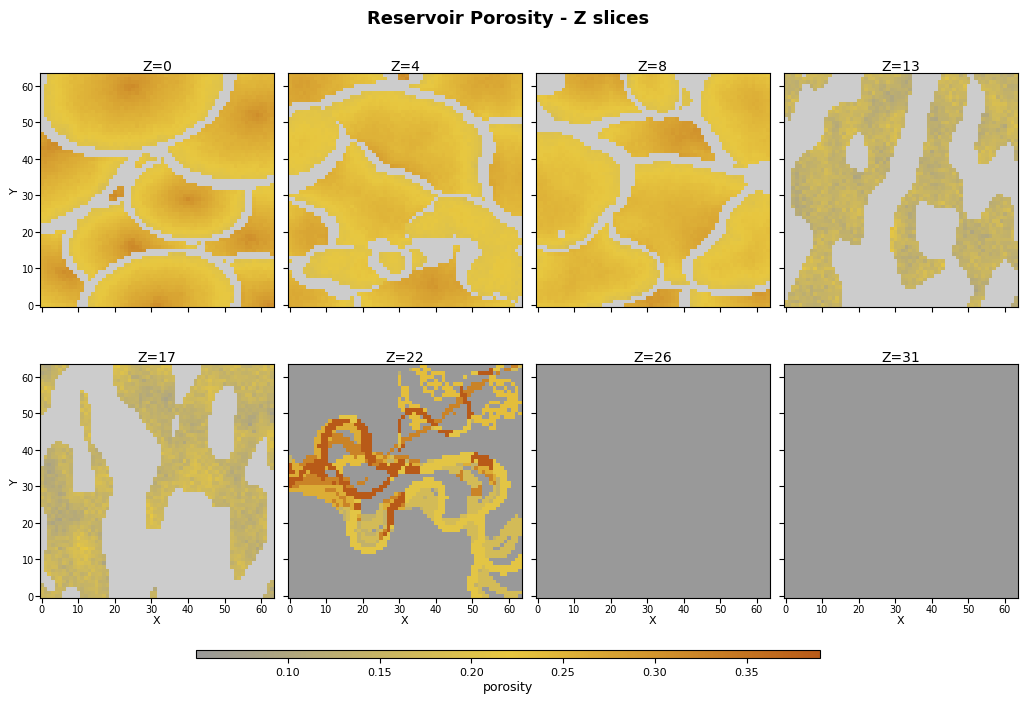

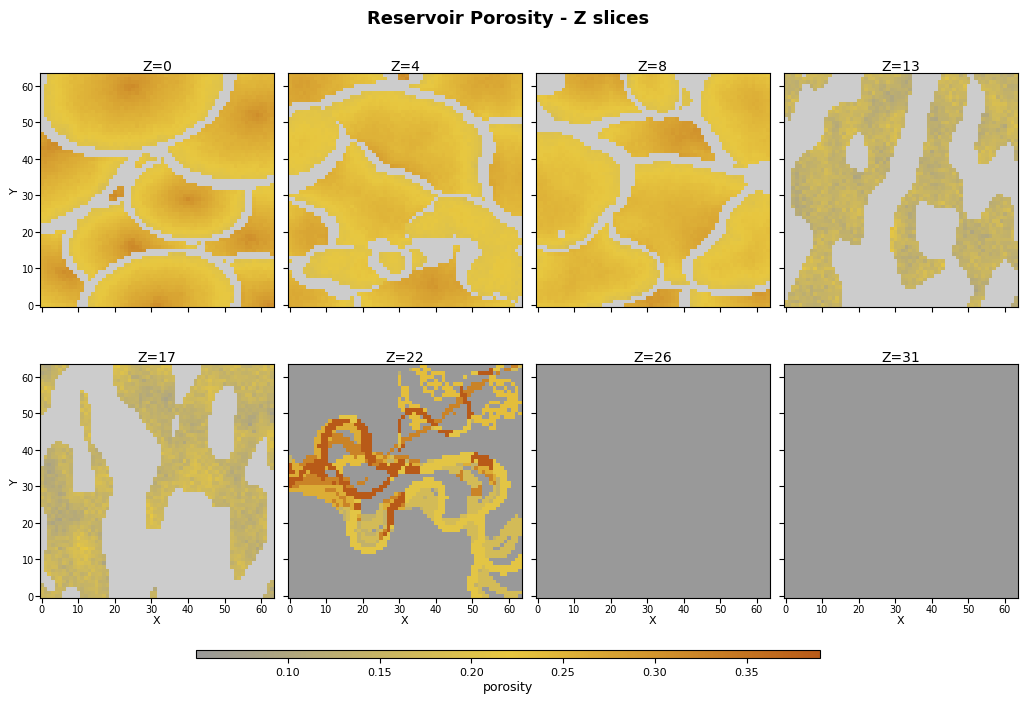

In [23]:
gr.plot_slices(reservoir.poro_mat, axis=2, title='Reservoir Porosity - Z slices')

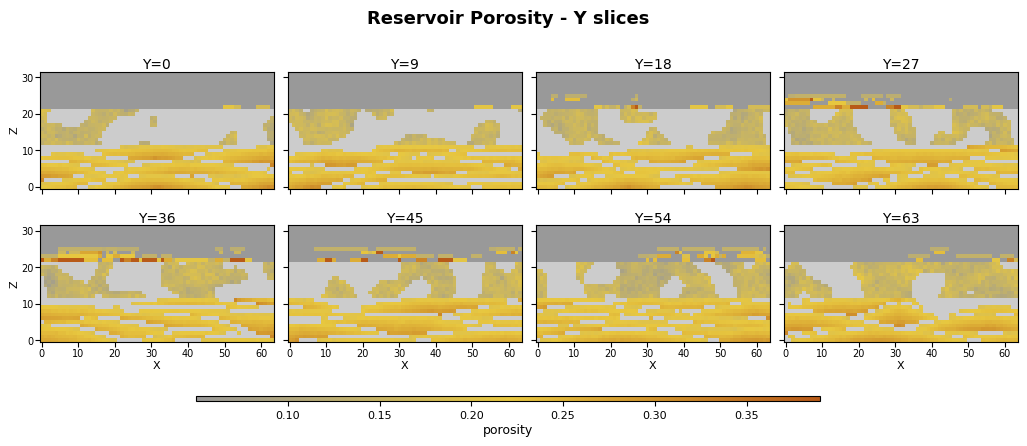

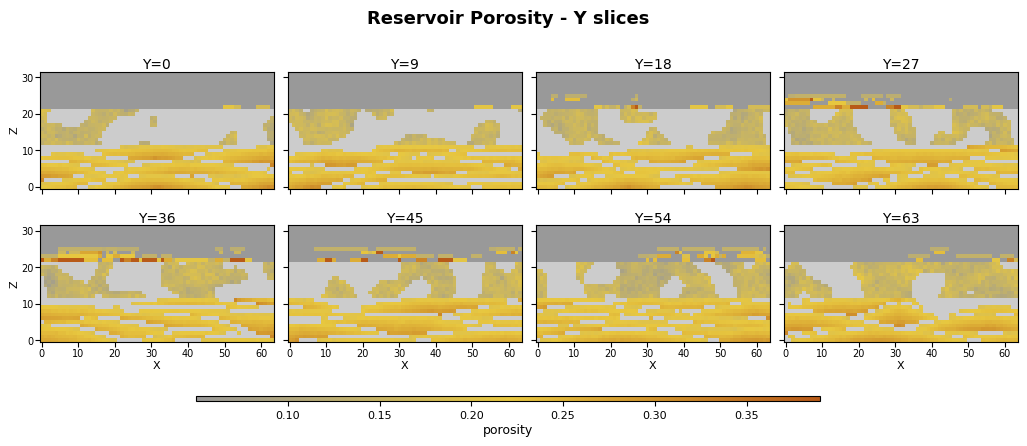

In [24]:
gr.plot_slices(reservoir.poro_mat, axis=1, title='Reservoir Porosity - Y slices')

(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': 'Reservoir Permeability (mD)'}, xlabel='X', ylabel='Y', zlabel='Z'>)

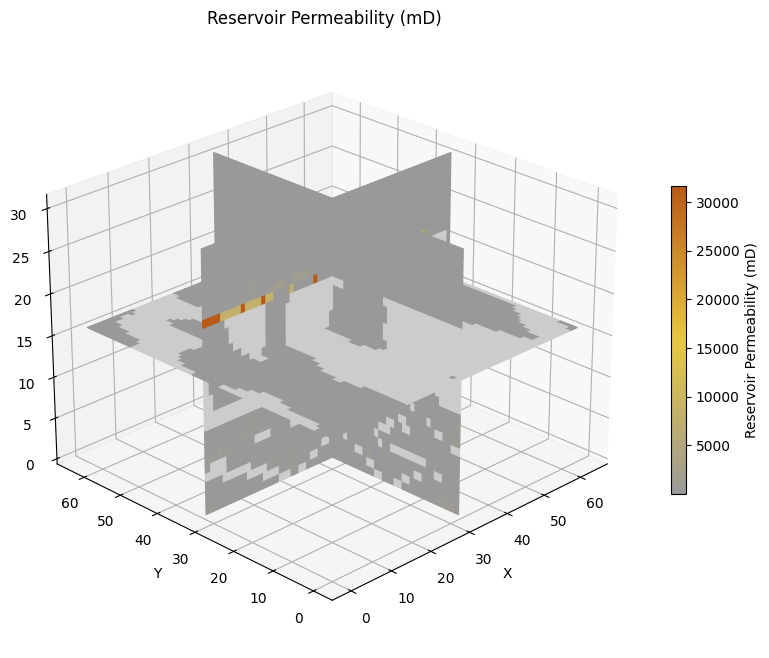

In [25]:
# Permeability view (uses same grey→yellow→orange colormap)
gr.plot_reservoir(reservoir, 'perm_mat', title='Reservoir Permeability (mD)')

## 5. Working with Raw Arrays

All model outputs are standard numpy arrays. You can use them directly
for further analysis, export, or input to simulation software.

In [26]:
# Access numpy arrays directly
poro = reservoir.poro_mat  # (nx, ny, nz)
perm = reservoir.perm_mat  # (nx, ny, nz) in millidarcies
active = reservoir.active  # (nx, ny, nz) binary

# Statistics on active cells only
active_poro = poro[active == 1]
print(f"Active cells porosity - mean: {active_poro.mean():.3f}, std: {active_poro.std():.3f}")
print(f"Active cells count: {active.sum()} / {active.size} ({active.mean()*100:.1f}%)")

# Save to file
# np.save('porosity.npy', poro)
# np.save('permeability.npy', perm)

Active cells porosity - mean: 0.203, std: 0.047
Active cells count: 61500 / 131072 (46.9%)


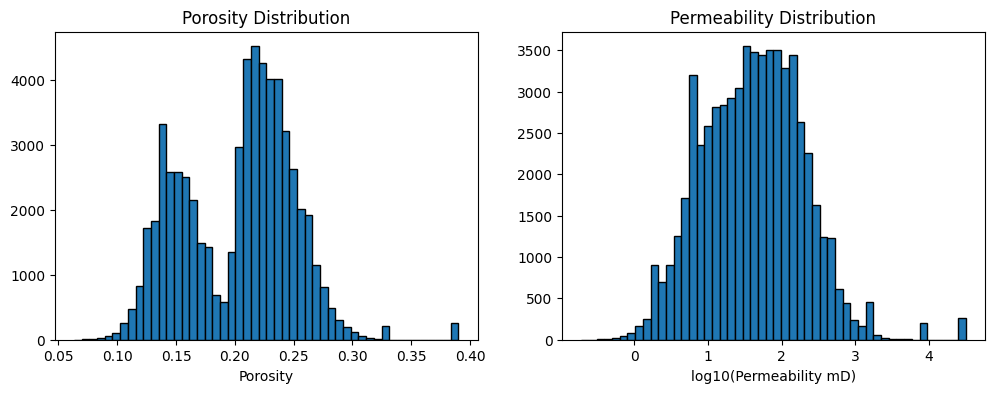

In [27]:
# Histogram of porosity in active cells
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(poro[active == 1], bins=50, edgecolor='black')
ax1.set_xlabel('Porosity')
ax1.set_title('Porosity Distribution')

ax2.hist(np.log10(perm[active == 1] + 1e-10), bins=50, edgecolor='black')
ax2.set_xlabel('log10(Permeability mD)')
ax2.set_title('Permeability Distribution')
plt.show()